# Session 1 — Make the Computer Do Your Boring Work

Twelve months of lab results, twelve messy files. By hand in Excel this is an afternoon. We are going to do it in a few lines, live, together.

**By the end of this session you can:**

- Open a data file in Python and see what is inside it
- Combine many files into one table without copy-paste
- Clean the three messes that show up in almost every real dataset
- Summarise a whole year with one line, and draw a plot you could put in a paper
- Read an error message instead of fearing it

You will not write programs from scratch today. The goal is to *read, run, and safely change* code — the skills you actually need on Monday.

## Setup (Google Colab only)

The cell below installs the two tools we use. **Run it first, before we start.** If Colab shows a *Restart* button after it finishes, click it — that is normal and only happens once. If you are not on Colab you can skip this cell.

In [ ]:
# Colab only. Run this first, before we start.
!pip install -q pandas==2.2.2 matplotlib==3.9.2
print("Libraries ready.")

## Load the tools

An **import** loads a toolbox someone else wrote. `pandas` is a spreadsheet that lives in Python; we nickname it `pd`. `matplotlib` draws charts; we nickname its drawing part `plt`. A **variable** is just a name we give to a value so we can reuse it — here `DATA_BASE_URL` holds the web address our data lives at, written once so we never retype it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

DATA_BASE_URL = "https://raw.githubusercontent.com/sanzidikawsar/python-crash-course/main/data/session1"

print("pandas version:", pd.__version__)

pandas version: 2.3.3


## The 30-minute Excel job, in six lines

We have twelve files, one per month, named `results_2025_01.csv` up to `results_2025_12.csv`. In Excel you would open each, copy, paste, and pray. Watch what happens instead. Do not worry about understanding every word yet — we take it apart right after.

In [2]:
all_months = []
for month in range(1, 13):
    file_url = f"{DATA_BASE_URL}/results_2025_{month:02d}.csv"
    all_months.append(pd.read_csv(file_url))

year = pd.concat(all_months, ignore_index=True)
print("Loaded", year.shape[0], "rows from 12 files")

Loaded 972 rows from 12 files


Here are the first rows of the whole year in one glance:

In [3]:
year.head()

,sample_id,treatment,replicate,absorbance,ph,date,Unnamed: 6
0,S01001,Treated,2.0,1.044,7.88,2025-01-01,NaN
1,S01002,Control,2.0,0.345,7.46,2025-01-28,NaN
2,S01003,TREATED,2.0,0.457,7.48,2025-01-18,NaN
3,S01004,Control,2.0,1.121,7.50,2025-01-18,NaN
4,S01005,control,3.0,0.203,7.18,2025-01-16,NaN


Now count how many rows belong to each treatment. Look closely at the result — something is already wrong, and spotting it is your first real data-cleaning instinct.

In [4]:
year["treatment"].value_counts()

treatment
Treated     371
Control     349
treated      47
control      43
TREATED      42
Control      40
CONTROL      39
treated      29
Name: count, dtype: int64

`Control`, `control`, and `CONTROL` are counted as three different things, even though they mean the same treatment. That is the kind of silent mess we will learn to fix. First, let's slow all the way down and understand what we just did.

## How a notebook works

A notebook is a stack of **cells**. A cell holds either text (like this one) or code. You run a code cell with **Shift + Enter**. The `[ ]` on the left becomes a number showing the order things ran in. Cells share memory: a variable made in one cell is available in the next. Run order matters — if you skip around, Python only knows what it has actually run.

In [5]:
sample_count = 81
print("rows in one file:", sample_count)

rows in one file: 81


Values come in types. A **number** you can do maths with; a **string** is text, written inside quotes. The `f"..."` below is an *f-string* — Python swaps anything in `{ }` for its value, so we can mix text and variables in one printed line.

In [6]:
treatment_name = "Control"
print(f"the treatment is {treatment_name}")

the treatment is Control


Code can make a decision with **`if`**: the indented line runs only when the condition is true. A pH above 7.5 is slightly basic, so:

In [7]:
newest_ph = 7.6
if newest_ph > 7.5:
    print("this sample is slightly basic")

this sample is slightly basic


A **list** is an ordered collection, written in square brackets. You reach an item by its position, and Python counts from **0**, so the first item is `[0]`. `len(...)` tells you how many items there are.

In [8]:
months = [1, 2, 3, 4, 5, 6]
print("first month:", months[0])
print("how many:", len(months))

first month: 1
how many: 6


### Break it on purpose

We are going to cause an error on purpose. Errors are not scars — they are the computer telling you exactly what it could not do. The single most useful habit today is to **read the last line first**. Here we ask for a variable name that does not exist:

In [9]:
print(monthss)

NameError: name 'monthss' is not defined

Read the traceback from the **bottom up**. The last line says `NameError: name 'monthss' is not defined`. `NameError` means *I have never heard of that name*. We simply misspelled `months`. The fix:

In [10]:
print(months)

[1, 2, 3, 4, 5, 6]


## Getting data in

This block is roughly 80% of everything you will ever do with data. We load **one** file first, so we can look at it slowly. `pd.read_csv(...)` reads a CSV file into a **DataFrame** — think of it as one sheet of a spreadsheet that Python can work on.

In [11]:
jan = pd.read_csv(f"{DATA_BASE_URL}/results_2025_01.csv")
jan.head()

,sample_id,treatment,replicate,absorbance,ph,date
0,S01001,Treated,2.0,1.044,7.88,2025-01-01
1,S01002,Control,2.0,0.345,7.46,2025-01-28
2,S01003,TREATED,2.0,0.457,7.48,2025-01-18
3,S01004,Control,2.0,1.121,7.50,2025-01-18
4,S01005,control,3.0,0.203,7.18,2025-01-16


`.head()` shows the first five rows. Two more everyday questions: how big is the table, and what kind of value is in each column?

In [12]:
print("rows, columns:", jan.shape)

rows, columns: (81, 6)


`.dtypes` lists the type of each column. `float64` means decimal numbers, `int64` whole numbers, `object` usually means text. Watch **`absorbance`** — it is a measurement, so we expect a number, but it comes in as `object`. That is a clue that something non-numeric is hiding in it.

In [13]:
jan.dtypes

sample_id      object
treatment      object
replicate     float64
absorbance     object
ph            float64
date           object
dtype: object

`.describe()` gives quick statistics for the number columns — count, mean, min, max. Notice `absorbance` is **missing** from this summary: pandas will not do statistics on a column it thinks is text. We will fix that shortly.

In [14]:
jan.describe()

,replicate,ph
count,80.000000,80.000000
mean,1.875000,7.164625
std,0.752633,0.437814
min,1.000000,6.430000
25%,1.000000,6.730000
50%,2.000000,7.150000
75%,2.000000,7.540000
max,3.000000,7.900000


To look at a single column, name it in square brackets:

In [15]:
jan["ph"].head()

0    7.88
1    7.46
2    7.48
3    7.50
4    7.18
Name: ph, dtype: float64

For several columns, pass a **list** of names — that is why there are two sets of brackets: the outer selects, the inner is the list.

In [16]:
jan[["sample_id", "ph"]].head()

,sample_id,ph
0,S01001,7.88
1,S01002,7.46
2,S01003,7.48
3,S01004,7.50
4,S01005,7.18


**Filtering** keeps only the rows that match a condition. The part inside the brackets, `jan["ph"] > 7.5`, is a true/false test for every row; pandas keeps the true ones.

In [17]:
high_ph = jan[jan["ph"] > 7.5]
print("high-pH rows:", high_ph.shape[0])
high_ph.head()

high-pH rows: 21


,sample_id,treatment,replicate,absorbance,ph,date
0,S01001,Treated,2.0,1.044,7.88,2025-01-01
6,S01007,Treated,3.0,0.732,7.72,2025-01-10
7,S01008,Treated,3.0,1.02,7.72,2025-01-24
9,S01010,Control,1.0,0.352,7.80,2025-01-19
10,S01011,Treated,1.0,0.095,7.87,2025-01-25


### Break it on purpose

The second error you will hit constantly: asking for a column name that is not exactly right. pandas is **case-sensitive** — `ph` and `PH` are different. Watch:

In [18]:
jan["PH"].head()

KeyError: 'PH'

Last line: `KeyError: 'PH'`. A `KeyError` means *that column name is not in the table*. Ninety percent of the time it is a typo or the wrong capitalisation. The column is `ph`, lower-case:

In [19]:
jan["ph"].head()

0    7.88
1    7.46
2    7.48
3    7.50
4    7.18
Name: ph, dtype: float64

Now the cleaning. `absorbance` loaded as text because a few cells contain `n.d.` (*not detected*) and a few are blank. `pd.to_numeric(..., errors="coerce")` turns the column into real numbers and quietly replaces anything it cannot convert with `NaN` (*not a number*, pandas' word for missing). One line fixes the whole column:

In [20]:
jan["absorbance"] = pd.to_numeric(jan["absorbance"], errors="coerce")
print("new type:", jan["absorbance"].dtype)
jan["absorbance"].describe()

new type: float64


count    72.000000
mean      0.779778
std       0.456866
min       0.094000
25%       0.380500
50%       0.714000
75%       1.170500
max       1.590000
Name: absorbance, dtype: float64

Second mess: the treatment labels. `.str.strip()` removes stray spaces and `.str.capitalize()` makes the casing consistent, so the three spellings of control collapse into one:

In [21]:
jan["treatment"] = jan["treatment"].str.strip().str.capitalize()
jan["treatment"].value_counts()

treatment
Treated    41
Control    39
Name: count, dtype: int64

Third mess: every file has one completely empty row. `dropna(how="all")` removes only the rows where *every* value is missing, leaving real data untouched:

In [22]:
jan = jan.dropna(how="all")
print("rows after cleaning:", jan.shape[0])

rows after cleaning: 80


## Doing it for all twelve files

A **`for` loop** repeats the same steps for each item in a list. `range(1, 13)` gives the numbers 1 through 12. Each time around we build that month's file name, read it, tag it with its month number, and add it to a growing list. At the end, `pd.concat` stacks them into one table. This is the loop from the hook — now you know every line.

In [23]:
all_months = []
for month in range(1, 13):
    file_url = f"{DATA_BASE_URL}/results_2025_{month:02d}.csv"
    monthly = pd.read_csv(file_url)
    monthly["month"] = month
    all_months.append(monthly)

year = pd.concat(all_months, ignore_index=True)
print("total rows:", year.shape[0])

total rows: 972


The same three fixes we did for January, now applied once to the whole year. One line each, and the entire dataset is clean:

In [24]:
year = year.dropna(how="all")
year["absorbance"] = pd.to_numeric(year["absorbance"], errors="coerce")
year["treatment"] = year["treatment"].str.strip().str.capitalize()
year.dtypes

sample_id      object
treatment      object
replicate     float64
absorbance    float64
ph            float64
date           object
month           int64
Unnamed: 6    float64
dtype: object

**`groupby`** is the loop you do not have to write. It splits the table into groups, computes one number per group, and hands back a tidy summary. Average absorbance for each treatment, in one line:

In [25]:
year.groupby("treatment")["absorbance"].mean()

treatment
Control    0.842439
Treated    0.829000
Name: absorbance, dtype: float64

Swap `.mean()` for `.count()` to ask how many samples are in each group:

In [26]:
year.groupby("treatment")["absorbance"].count()

treatment
Control    426
Treated    438
Name: absorbance, dtype: int64

Group by `month` instead, and we get the average for every month of the year — a twelve-row table that is begging to be a plot:

In [27]:
monthly_mean = year.groupby("month")["absorbance"].mean()
monthly_mean

month
1     0.779778
2     0.872653
3     0.868125
4     0.801167
5     0.771792
6     0.926931
7     0.796347
8     0.840653
9     0.774750
10    0.846736
11    0.823083
12    0.925500
Name: absorbance, dtype: float64

## One picture worth keeping

`plt.plot` draws the monthly averages as a line. Always label the axes and give the plot a title — an unlabelled plot is useless to a reader. `plt.savefig` writes it to an image file you could drop straight into a paper or a slide.

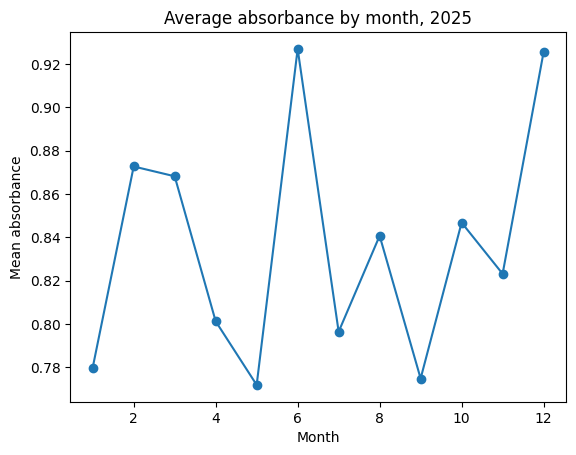

In [28]:
plt.plot(monthly_mean.index, monthly_mean.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Mean absorbance")
plt.title("Average absorbance by month, 2025")
plt.savefig("absorbance_by_month.png", dpi=150)
plt.show()

A different question — how do the two treatments compare overall? — wants a different picture. `plt.bar` draws one bar per group:

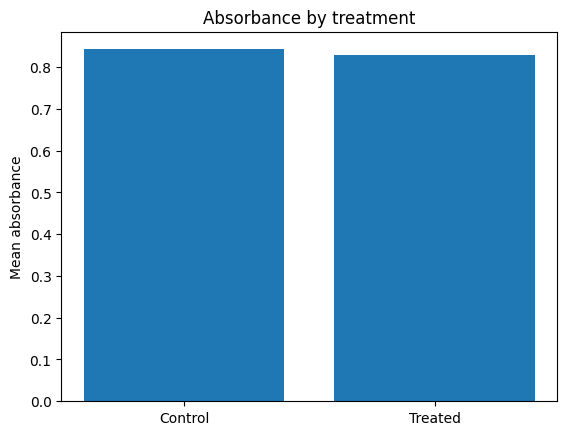

In [29]:
treatment_mean = year.groupby("treatment")["absorbance"].mean()
plt.bar(treatment_mean.index, treatment_mean.values)
plt.ylabel("Mean absorbance")
plt.title("Absorbance by treatment")
plt.show()

## Your turn

**What you can now do**, and could not an hour ago: open a data file, combine many of them, clean the three everyday messes, summarise with `groupby`, and draw a labelled plot. That is a real chunk of a research workflow.

**What to try in the homework** (on *your own* data file):

- Read your file with `pd.read_csv` and run `.head()`, `.shape`, `.dtypes`
- Find one column that loaded as `object` but should be a number, and fix it
- Filter to a subset of rows that matters to you, and count them
- Use `groupby` to get one number per group
- Draw one labelled plot and save it as a PNG
- For every answer, write one sentence: *how did you check it was right?*

Bring the notebook — working or broken — to next session. A broken cell with its error message is exactly what we want to look at together.